# Part 1: NAS 개념 및 Baseline 학습

## 이 노트북에서 다루는 내용
1. Neural Architecture Search (NAS)의 핵심 개념
2. 탐색 공간(Search Space) 정의 및 분석
3. CNN 모델 학습 (Baseline)
4. 샘플 아키텍처 시각화 및 비교

## NAS 핵심 개념

**Neural Architecture Search (NAS)**: 사람이 설계하는 대신, 알고리즘이 최적의 아키텍처를 자동으로 탐색

### NAS의 3가지 핵심 요소

| 요소 | 설명 | 이 튜토리얼 |
|------|------|-------------|
| Search Space | 어떤 아키텍처를 탐색할 것인가? | 필터 수, 커널 크기, FC hidden |
| Search Strategy | 어떻게 탐색할 것인가? | Random Search, Evolutionary |
| Performance Estimation | 성능을 어떻게 빠르게 평가? | Reduced Training (5 epochs) |

### 주요 탐색 전략
- **Random Search**: 무작위 샘플링 (간단하지만 놀라울 정도로 효과적)
- **Evolutionary**: 유전 알고리즘 기반 (mutation, selection)
- **RL-based**: 강화학습 기반 (Zoph & Le, 2017)
- **Gradient-based**: 미분 가능한 탐색 (DARTS, Liu et al., 2019)

## [1] 환경 설정 및 데이터 로드

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import (
    CNN, FlexibleCNN, SEARCH_SPACE,
    sample_architecture, get_search_space_size, architecture_to_string
)

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10
SEED = 42
torch.manual_seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

100%|██████████| 170M/170M [00:17<00:00, 9.99MB/s] 


학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 탐색 공간(Search Space) 분석

In [3]:
print("탐색 공간 구성:")
print(f"  Conv 필터 수 후보: {SEARCH_SPACE['filters']}")
print(f"  Conv 커널 크기 후보: {SEARCH_SPACE['kernel_sizes']}")
print(f"  FC Hidden Units 후보: {SEARCH_SPACE['fc_hidden']}")
print(f"  Conv 레이어 수: {SEARCH_SPACE['num_conv_layers']} (고정)")
print(f"  MaxPool 위치: {SEARCH_SPACE['pool_after']} (고정, 0-indexed)")

n_filters = len(SEARCH_SPACE['filters'])
n_kernels = len(SEARCH_SPACE['kernel_sizes'])
n_fc = len(SEARCH_SPACE['fc_hidden'])
n_conv = SEARCH_SPACE['num_conv_layers']

total_size = get_search_space_size()
print(f"\n전체 탐색 공간 크기: {total_size:,} 가지 아키텍처")
print(f"  = (필터 {n_filters} x 커널 {n_kernels})^{n_conv} x FC {n_fc}")
print(f"  = {n_filters * n_kernels}^{n_conv} x {n_fc}")
print(f"  = {(n_filters * n_kernels) ** n_conv:,} x {n_fc}")

탐색 공간 구성:
  Conv 필터 수 후보: [16, 32, 64, 128]
  Conv 커널 크기 후보: [3, 5]
  FC Hidden Units 후보: [128, 256, 512, 1024]
  Conv 레이어 수: 4 (고정)
  MaxPool 위치: [1, 3] (고정, 0-indexed)

전체 탐색 공간 크기: 16,384 가지 아키텍처
  = (필터 4 x 커널 2)^4 x FC 4
  = 8^4 x 4
  = 4,096 x 4


## [3] 학습 및 평가 함수 정의

In [4]:
def train(model, train_loader, epochs, learning_rate, device):
    """Cross-Entropy 학습"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses


def test(model, test_loader, device):
    """모델 평가"""
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy


def count_parameters(model):
    """모델의 총 파라미터 수 계산"""
    return sum(p.numel() for p in model.parameters())

## [4] CNN 모델 학습 (Baseline)

In [5]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

baseline_params = count_parameters(model)
print(f"CNN 모델 파라미터 수: {baseline_params:,}")
print(f"\n모델 구조:")
print(model)

CNN 모델 파라미터 수: 1,186,986

모델 구조:
CNN(
  (features): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [6]:
# 학습
train_losses = train(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
baseline_accuracy = test(model, test_loader, DEVICE)

Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347
Test Accuracy: 75.01%


## [5] 샘플 아키텍처 시각화

In [7]:
# 탐색 공간에서 10개 아키텍처 샘플링
num_samples = 10
architectures = []

for i in range(num_samples):
    arch = sample_architecture(seed=SEED + i)
    flex_model = FlexibleCNN(arch, num_classes=NUM_CLASSES)
    params = count_parameters(flex_model)
    architectures.append({
        'arch': arch,
        'params': params,
        'name': architecture_to_string(arch)
    })

# 파라미터 수 기준 정렬
architectures.sort(key=lambda x: x['params'])

for i, a in enumerate(architectures):
    print(f"  Arch {i+1}: {a['name']} | Params: {a['params']:,}")

  Arch 1: F[16-64-128-16]_K[5-3-3-5]_FC256 | Params: 203,930
  Arch 2: F[16-128-16-32]_K[3-3-3-3]_FC512 | Params: 309,882
  Arch 3: F[32-32-32-32]_K[5-5-5-5]_FC512 | Params: 347,114
  Arch 4: F[128-16-32-128]_K[3-5-3-3]_FC128 | Params: 359,994
  Arch 5: F[16-64-32-128]_K[5-3-5-5]_FC128 | Params: 427,818
  Arch 6: F[128-64-64-32]_K[5-5-3-5]_FC256 | Params: 436,650
  Arch 7: F[16-16-64-32]_K[3-3-3-3]_FC1024 | Params: 566,074
  Arch 8: F[64-32-64-32]_K[5-3-3-3]_FC1024 | Params: 595,850
  Arch 9: F[64-16-128-128]_K[5-5-5-5]_FC128 | Params: 755,098
  Arch 10: F[64-128-128-64]_K[3-5-5-3]_FC128 | Params: 822,730


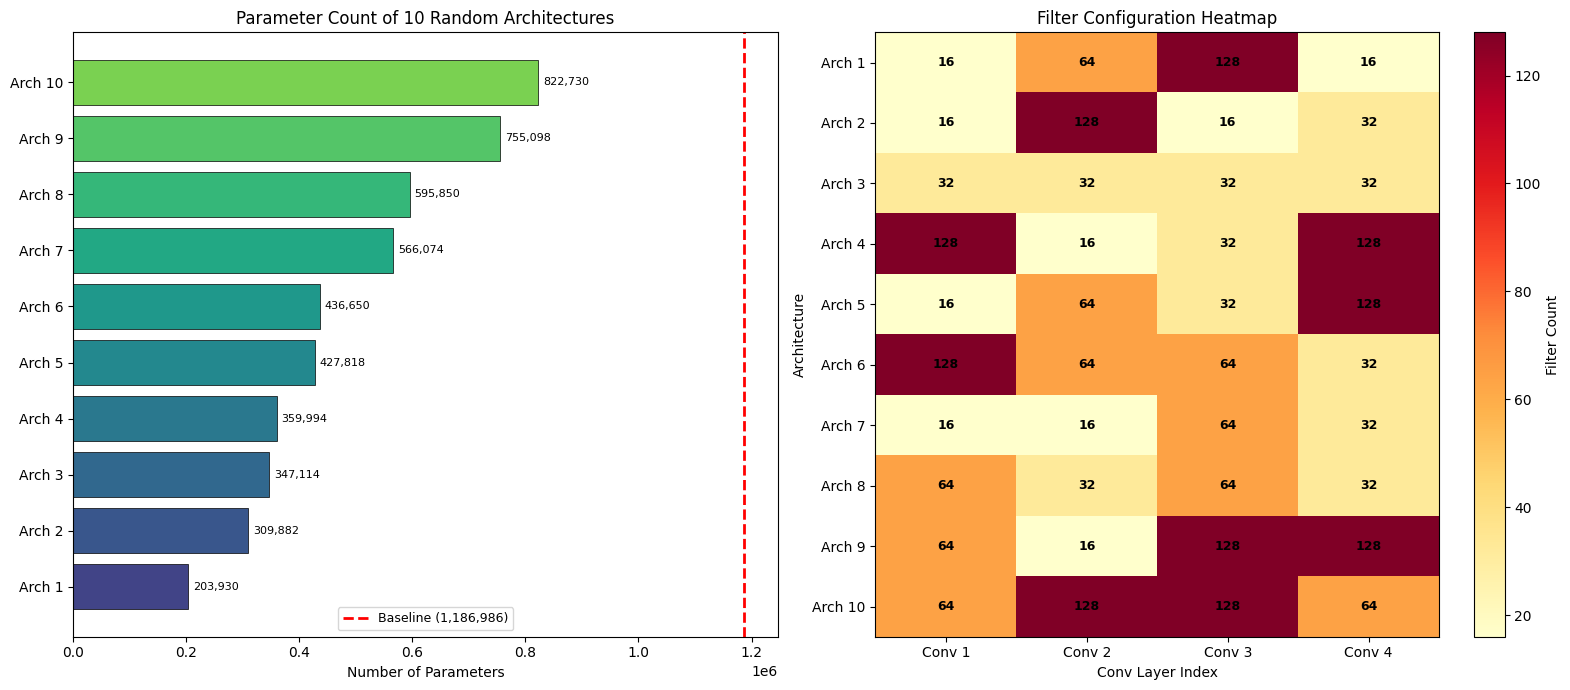

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: 파라미터 수 비교 ---
ax1 = axes[0]
names = [f"Arch {i+1}" for i in range(num_samples)]
params_list = [a['params'] for a in architectures]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_samples))

bars = ax1.barh(names, params_list, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Number of Parameters')
ax1.set_title(f'Parameter Count of {num_samples} Random Architectures')

for bar, params in zip(bars, params_list):
    ax1.text(bar.get_width() + max(params_list) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{params:,}', va='center', fontsize=8)

ax1.axvline(x=baseline_params, color='red', linestyle='--', linewidth=2,
            label=f'Baseline ({baseline_params:,})')
ax1.legend(fontsize=9)

# --- Plot 2: 필터 구성 히트맵 ---
ax2 = axes[1]
filter_matrix = np.array([a['arch']['filters'] for a in architectures])
im = ax2.imshow(filter_matrix, cmap='YlOrRd', aspect='auto')
ax2.set_xlabel('Conv Layer Index')
ax2.set_ylabel('Architecture')
ax2.set_title('Filter Configuration Heatmap')
ax2.set_xticks(range(SEARCH_SPACE['num_conv_layers']))
ax2.set_xticklabels([f'Conv {i+1}' for i in range(SEARCH_SPACE['num_conv_layers'])])
ax2.set_yticks(range(num_samples))
ax2.set_yticklabels(names)

for i in range(num_samples):
    for j in range(SEARCH_SPACE['num_conv_layers']):
        ax2.text(j, i, str(filter_matrix[i, j]),
                 ha='center', va='center', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax2, label='Filter Count')
plt.tight_layout()
plt.show()

## [6] FlexibleCNN 동작 확인

In [10]:
test_arch = sample_architecture(seed=SEED)
test_model = FlexibleCNN(test_arch, num_classes=NUM_CLASSES)
test_input = torch.randn(1, 3, 32, 32)
test_output = test_model(test_input)

print(f"아키텍처: {architecture_to_string(test_arch)}")
print(f"파라미터 수: {count_parameters(test_model):,}")
print(f"입력 shape: {list(test_input.shape)}")
print(f"출력 shape: {list(test_output.shape)}")
print(f"\n모델 구조:")
print(test_model)

아키텍처: F[16-16-64-32]_K[3-3-3-3]_FC1024
파라미터 수: 566,074
입력 shape: [1, 3, 32, 32]
출력 shape: [1, 10]

모델 구조:
FlexibleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=10, bias=True)
  )
)


## 결과 요약

In [11]:
print("=" * 60)
print("결과 요약")
print("=" * 60)
print(f"탐색 공간 크기: {total_size:,} 가지 아키텍처")
print(f"Baseline 모델: CNN ({baseline_params:,} parameters)")
print(f"Baseline 정확도: {baseline_accuracy:.2f}%")
print(f"\n다음 단계:")
print(f"  - Part 2: Random Search로 최적 아키텍처 탐색")
print(f"  - Part 3: Evolutionary Search로 더 효율적인 탐색")
print(f"  - Part 4: 전체 실험 결과 종합 분석")

결과 요약
탐색 공간 크기: 16,384 가지 아키텍처
Baseline 모델: CNN (1,186,986 parameters)
Baseline 정확도: 75.01%

다음 단계:
  - Part 2: Random Search로 최적 아키텍처 탐색
  - Part 3: Evolutionary Search로 더 효율적인 탐색
  - Part 4: 전체 실험 결과 종합 분석
